In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import os
for dirname,_,filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df=pd.read_csv('/kaggle/input/datasets/kanchana1990/ai-and-ml-job-listings-usa/ai_ml_jobs_linkedin.csv')


/kaggle/input/datasets/kanchana1990/ai-and-ml-job-listings-usa/ai_ml_jobs_linkedin.csv


In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 862 entries, 0 to 861
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   title              862 non-null    object
 1   location           862 non-null    object
 2   publishedAt        850 non-null    object
 3   companyName        861 non-null    object
 4   description        862 non-null    object
 5   applicationsCount  862 non-null    object
 6   contractType       862 non-null    object
 7   experienceLevel    862 non-null    object
 8   workType           862 non-null    object
 9   sector             859 non-null    object
dtypes: object(10)
memory usage: 67.5+ KB


In [4]:
print(df.columns)
df.head()
     

Index(['title', 'location', 'publishedAt', 'companyName', 'description',
       'applicationsCount', 'contractType', 'experienceLevel', 'workType',
       'sector'],
      dtype='object')


,title,location,publishedAt,companyName,description,applicationsCount,contractType,experienceLevel,workType,sector
0,AI/ML Engineer,"New York, NY",2024-05-29,Wesper,THE OPPORTUNITY\n\nWesper is looking for a sma...,Over 200 applicants,Full-time,Mid-Senior level,Engineering and Information Technology,Internet Publishing
1,Software Engineer - AI/ML Systems,"Redwood City, CA",NaN,Snorkel AI,We're on a mission to democratize AI by buildi...,51 applicants,Full-time,Entry level,Engineering and Information Technology,Software Development
2,ML Engineer at 100% Remote,"San Jose, CA",2024-06-01,ELITE MENTE LLC,"Hello ,\n\nHope you are doing well!\n\nPlease ...",Be among the first 25 applicants,Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting
3,Machine Learning Engineer (L4) - Infrastructur...,"Los Gatos, CA",2024-05-19,Netflix,At Netflix our goal is to entertain the world....,Over 200 applicants,Full-time,Not Applicable,Engineering and Information Technology,"Entertainment Providers, Technology, Informati..."
4,Data Scientist / ML Engineer,"Redwood City, CA",NaN,"Paradyme, Inc.",Overview\n\nParadyme Management is a rapidly g...,110 applicants,Full-time,Entry level,Engineering and Information Technology,IT Services and IT Consulting


In [5]:
# Filter for Entry level jobs
entry_level_jobs = df[df['experienceLevel'] == 'Entry level']

# Show the first 5 entry level jobs
entry_level_jobs[['title', 'companyName', 'location']].head()

,title,companyName,location
1,Software Engineer - AI/ML Systems,Snorkel AI,"Redwood City, CA"
2,ML Engineer at 100% Remote,ELITE MENTE LLC,"San Jose, CA"
4,Data Scientist / ML Engineer,"Paradyme, Inc.","Redwood City, CA"
5,ML Engineer-AI/ML,Zortech Solutions,"Austin, TX"
6,Junior Machine Learning Engineer,HireMeFast LLC,"Boulder, CO"


/tmp/ipykernel_16/3794265402.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experienceLevel', y='clean_apps', palette='Set2')


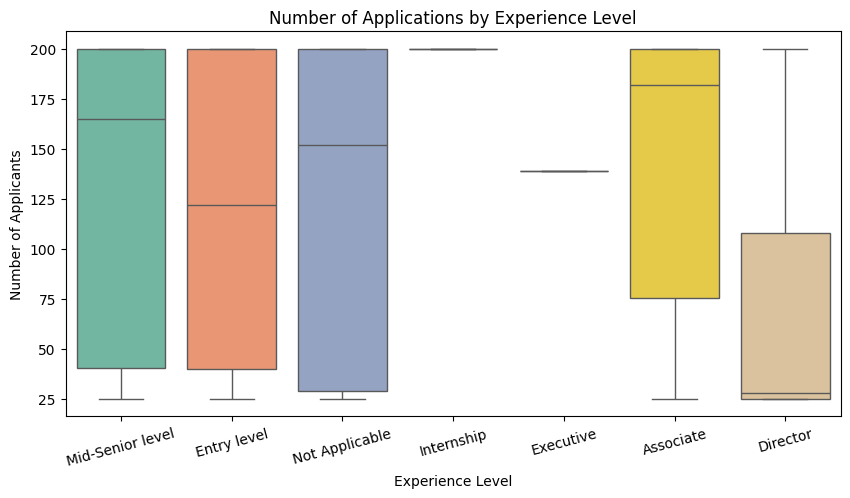

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. A little bit of cleaning magic to turn text into numbers
df['clean_apps'] = df['applicationsCount'].str.extract(r'(\d+)').astype(float)
df['clean_apps'] = df['clean_apps'].fillna(25) # If it says "Be among first 25", we count it as 25

# 2. Plot a beautiful boxplot chart using Seaborn
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='experienceLevel', y='clean_apps', palette='Set2')

# 3. Customize the chart labels
plt.title('Number of Applications by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=15)

plt.show()

/tmp/ipykernel_16/3813551474.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experienceLevel', y='clean_apps', palette='Set2')


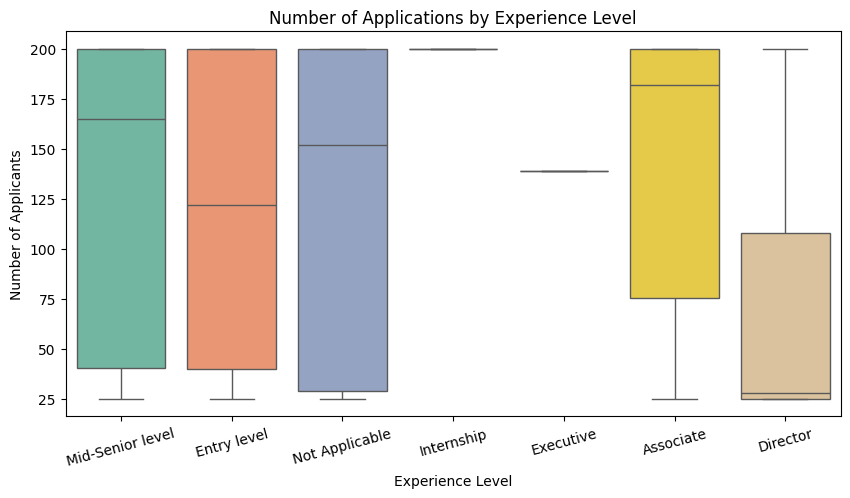

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Fixed with the 'r' prefix to avoid the escape sequence error!
df['clean_apps'] = df['applicationsCount'].str.extract(r'(\d+)').astype(float)
df['clean_apps'] = df['clean_apps'].fillna(25) 

# 2. Plot a beautiful boxplot chart using Seaborn
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='experienceLevel', y='clean_apps', palette='Set2')

# 3. Customize the chart labels
plt.title('Number of Applications by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=15)

plt.show()

In [8]:
print(df.isnull().sum())

title                 0
location              0
publishedAt          12
companyName           1
description           0
applicationsCount     0
contractType          0
experienceLevel       0
workType              0
sector                3
clean_apps            0
dtype: int64


In [9]:
df = df.dropna()

In [10]:
print(df.shape)
print(df.isnull().sum())

(847, 11)
title                0
location             0
publishedAt          0
companyName          0
description          0
applicationsCount    0
contractType         0
experienceLevel      0
workType             0
sector               0
clean_apps           0
dtype: int64


In [11]:
duplicates = df.duplicated().sum()
print(duplicates)

3


In [12]:
df = df.drop_duplicates()

In [13]:
print(df['companyName'].value_counts().head(10))
print(df['experienceLevel'].value_counts())

companyName
Unreal Staffing, Inc           42
DoorDash                       25
Grammarly                      18
Steneral Consulting            17
Samsung Electronics America    14
Diverse Lynx                   11
Stripe                         10
Adobe                           9
Triunity Software, Inc.         8
Netflix                         7
Name: count, dtype: int64
experienceLevel
Mid-Senior level    398
Entry level         322
Not Applicable       73
Associate            34
Internship            9
Director              7
Executive             1
Name: count, dtype: int64


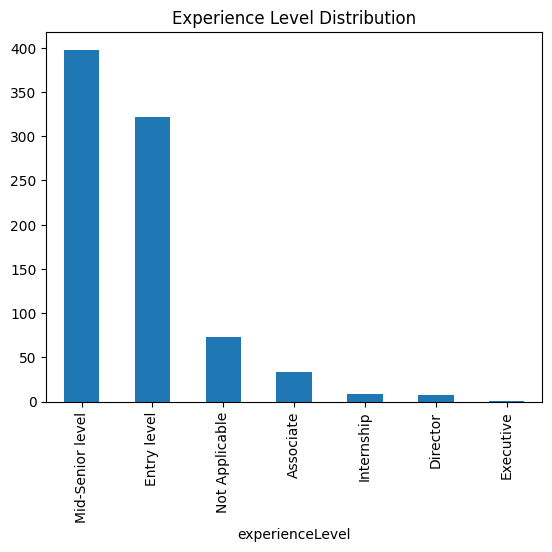

In [14]:
import matplotlib.pyplot as plt

df['experienceLevel'].value_counts().plot(kind='bar')
plt.title('Experience Level Distribution')
plt.show()

In [15]:
print(df['workType'].value_counts())
print(df['contractType'].value_counts())

workType
Engineering and Information Technology                         546
Engineering                                                    129
Information Technology                                          71
Information Technology and Engineering                          21
Other                                                           13
Engineering, Information Technology, and Research                4
Research and Engineering                                         3
Science                                                          3
Research, Analyst, and Information Technology                    2
Analyst                                                          2
Information Technology, Engineering, and Other                   2
Finance and Consulting                                           2
Business Development and Sales                                   2
Research, Information Technology, and Engineering                2
Engineering, Information Technology, and Legal       

In [16]:
import pandas as pd
import sqlite3

file_path = "/kaggle/input/datasets/kanchana1990/ai-and-ml-job-listings-usa/ai_ml_jobs_linkedin.csv"

df = pd.read_csv(file_path)

conn = sqlite3.connect("jobpulse.db")

df.to_sql("jobs", conn, if_exists="replace", index=False)

print("Database created successfully!")

Database created successfully!


In [17]:
print(df.columns)

Index(['title', 'location', 'publishedAt', 'companyName', 'description',
       'applicationsCount', 'contractType', 'experienceLevel', 'workType',
       'sector'],
      dtype='object')


In [18]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("jobpulse.db")

In [19]:
pd.read_sql("""
SELECT companyName, COUNT(*) AS job_count
FROM jobs
GROUP BY companyName
ORDER BY job_count DESC
LIMIT 10;
""", conn)

,companyName,job_count
0,"Unreal Staffing, Inc",45
1,DoorDash,25
2,Grammarly,18
3,Steneral Consulting,17
4,Samsung Electronics America,14
5,Diverse Lynx,11
6,Stripe,10
7,Adobe,9
8,"Triunity Software, Inc.",8
9,Netflix,7


In [20]:
pd.read_sql("""
SELECT location, COUNT(*) AS job_count
FROM jobs
GROUP BY location
ORDER BY job_count DESC
LIMIT 10;
""", conn)

,location,job_count
0,United States,140
1,"San Francisco, CA",95
2,"New York, NY",72
3,"Seattle, WA",30
4,"Mountain View, CA",23
5,"Irving, TX",23
6,"Palo Alto, CA",21
7,"San Jose, CA",19
8,"Sunnyvale, CA",18
9,San Francisco Bay Area,18


In [21]:
# sector demand

In [22]:
pd.read_sql("""
SELECT sector, COUNT(*) AS job_count
FROM jobs
GROUP BY sector
ORDER BY job_count DESC
LIMIT 10;
""", conn)

,sector,job_count
0,Software Development,197
1,IT Services and IT Consulting,128
2,"Technology, Information and Internet",77
3,Non-profit Organizations and Primary and Secon...,65
4,Staffing and Recruiting,43
5,Information Technology & Services,20
6,Internet Publishing,18
7,Computers and Electronics Manufacturing,17
8,Financial Services,14
9,Defense and Space Manufacturing,11


In [23]:
top_companies = pd.read_sql("""
SELECT companyName, COUNT(*) AS job_count
FROM jobs
GROUP BY companyName
ORDER BY job_count DESC
LIMIT 10;
""", conn)

top_companies.to_csv("top_companies.csv", index=False)

In [24]:
skills = [
    "python", "sql", "machine learning", "deep learning",
    "tensorflow", "pytorch", "keras",
    "aws", "azure", "gcp",
    "excel", "power bi", "tableau",
    "nlp", "data analysis", "statistics"
]

In [25]:
import pandas as pd

def extract_skills(text):
    text = str(text).lower()
    found_skills = []

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return ", ".join(found_skills)

df["extracted_skills"] = df["description"].apply(extract_skills)

df[["title", "extracted_skills"]].head()

,title,extracted_skills
0,AI/ML Engineer,"python, deep learning"
1,Software Engineer - AI/ML Systems,"python, machine learning, deep learning, pytor..."
2,ML Engineer at 100% Remote,"python, gcp, statistics"
3,Machine Learning Engineer (L4) - Infrastructur...,"python, machine learning, tensorflow, pytorch,..."
4,Data Scientist / ML Engineer,"python, machine learning, deep learning, aws, ..."


In [26]:
from collections import Counter

all_skills = df["extracted_skills"].str.split(", ").sum()
skill_counts = Counter(all_skills)

skill_df = pd.DataFrame(skill_counts.items(), columns=["skill", "count"])
skill_df = skill_df.sort_values(by="count", ascending=False)

skill_df.head(10)

,skill,count
0,python,707
2,machine learning,691
10,excel,386
3,pytorch,383
8,aws,336
7,tensorflow,333
1,deep learning,250
9,azure,185
12,sql,185
6,statistics,177


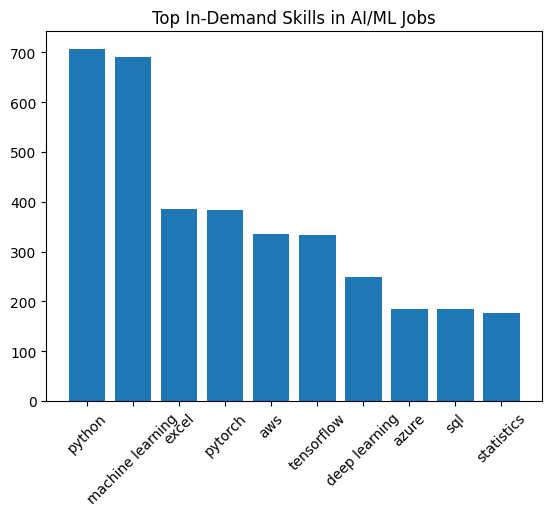

In [27]:
import matplotlib.pyplot as plt

top_skills = skill_df.head(10)

plt.bar(top_skills["skill"], top_skills["count"])
plt.xticks(rotation=45)
plt.title("Top In-Demand Skills in AI/ML Jobs")
plt.show()